# Lab 10 - Numerical Integration I

Solutions for all tasks from `L10_NC.pdf`, implemented in Python.

All formulas follow `NC_lecture9.pdf` (Chapter 4, Section 3):

- Composite rectangle (midpoint), eq. (3.6): $\int_a^b f(x)\,dx \approx h \sum_{i=0}^{n-1} f\!\left(a + (i+\tfrac{1}{2})h\right)$, error $-\tfrac{h^2(b-a)}{24}f''(\xi)$.
- Composite trapezoidal, eq. (3.8): $\int_a^b f(x)\,dx \approx \tfrac{h}{2}\big[f(a) + 2\sum_{i=1}^{n-1} f_i + f(b)\big]$, error $-\tfrac{h^2(b-a)}{12}f''(\xi)$.
- Composite Simpson, eq. (3.10) with $n=2m$: $\int_a^b f(x)\,dx \approx \tfrac{h}{3}\big[f(a) + 4\sum_{i=1}^{m} f_{2i-1} + 2\sum_{i=1}^{m-1} f_{2i} + f(b)\big]$, error $-\tfrac{h^4(b-a)}{180} f^{(4)}(\xi)$.
- Adaptive quadrature follows Algorithm 3.1: compute $I_1 = \text{met}(f,a,b,m)$ and $I_2 = \text{met}(f,a,b,2m)$, accept $I_2$ if $|I_1 - I_2| < \varepsilon$, otherwise recurse on the two halves.

Theoretical convergence rates: rectangle and trapezoidal are $O(h^2)$ (so halving $h$ should divide the error by ~4), while Simpson is $O(h^4)$ (ratio ~16).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf as scipy_erf
from scipy.integrate import quad

np.set_printoptions(precision=10, suppress=True)


## 1. Composite Newton-Cotes formulas

Implementations of the three composite rules from the lecture. Inputs are evaluated in a single vectorized pass over the equally spaced nodes.

In [4]:
def composite_rectangle(f, a, b, n):
    if n < 1:
        raise ValueError("n must be at least 1")
    h = (b - a) / n
    midpoints = a + (np.arange(n) + 0.5) * h
    return h * np.sum(f(midpoints))


def composite_trapezoidal(f, a, b, n):
    if n < 1:
        raise ValueError("n must be at least 1")
    h = (b - a) / n
    x = a + np.arange(n + 1) * h
    y = f(x)
    return h * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5 * y[-1])


def composite_simpson(f, a, b, n):
    if n < 2 or n % 2 != 0:
        raise ValueError("Simpson's rule requires an even n >= 2")
    h = (b - a) / n
    x = a + np.arange(n + 1) * h
    y = f(x)
    return (h / 3.0) * (y[0] + 4.0 * np.sum(y[1:-1:2]) + 2.0 * np.sum(y[2:-1:2]) + y[-1])


Quick sanity check on $\int_0^1 \frac{1}{1+x}\,dx = \ln 2$ (Example 3.7 from the lecture, with $n = 1$ and $n = 2$ for Simpson):

In [5]:
f_check = lambda x: 1.0 / (1.0 + x)
exact = np.log(2)
print(f"exact            = {exact:.10f}")
print(f"rectangle  n=1  -> {composite_rectangle(f_check, 0, 1, 1):.10f}  (lecture: 2/3 = {2/3:.4f})")
print(f"trapezoidal n=1 -> {composite_trapezoidal(f_check, 0, 1, 1):.10f}  (lecture: 3/4 = {3/4:.4f})")
print(f"Simpson    n=2  -> {composite_simpson(f_check, 0, 1, 2):.10f}  (lecture: 25/36 = {25/36:.4f})")


exact            = 0.6931471806
rectangle  n=1  -> 0.6666666667  (lecture: 2/3 = 0.6667)
trapezoidal n=1 -> 0.7500000000  (lecture: 3/4 = 0.7500)
Simpson    n=2  -> 0.6944444444  (lecture: 25/36 = 0.6944)


## 2. Adaptive quadratures

Following Algorithm 3.1: accept $I_2$ when $|I_1 - I_2| < \varepsilon$, else split the interval and recurse. The starting `m` is the number of subintervals used by the composite rule on the current piece (Simpson needs `m` even).

In [6]:
def adaptive_quadrature(f, a, b, eps, met, m, max_depth=50):
    def recurse(a, b, depth):
        I1 = met(f, a, b, m)
        I2 = met(f, a, b, 2 * m)
        if abs(I1 - I2) < eps or depth >= max_depth:
            return I2
        mid = 0.5 * (a + b)
        return recurse(a, mid, depth + 1) + recurse(mid, b, depth + 1)

    return recurse(a, b, 0)


def adaptive_rectangle(f, a, b, eps=1e-6, m=2):
    return adaptive_quadrature(f, a, b, eps, composite_rectangle, m)


def adaptive_trapezoidal(f, a, b, eps=1e-6, m=2):
    return adaptive_quadrature(f, a, b, eps, composite_trapezoidal, m)


def adaptive_simpson(f, a, b, eps=1e-6, m=2):
    return adaptive_quadrature(f, a, b, eps, composite_simpson, m)


## Application 1 - approximating $\ln 2$ with 3 correct decimals

We integrate $I = \int_1^2 \frac{dx}{x} = \ln 2$. "3 correct decimals" means $|\text{error}| \le 0.5 \cdot 10^{-3}$.

Using the lecture error bounds with $f(x) = 1/x$ on $[1,2]$ ($\max|f''| = 2$, $\max|f^{(4)}| = 24$):

- rectangle: $\dfrac{(b-a)h^2}{24}\max|f''| = \dfrac{1}{12 n^2} \le 5\cdot 10^{-4} \Rightarrow n \ge 13$.
- trapezoidal: $\dfrac{(b-a)h^2}{12}\max|f''| = \dfrac{1}{6 n^2} \le 5\cdot 10^{-4} \Rightarrow n \ge 19$.
- Simpson: $\dfrac{(b-a)h^4}{180}\max|f^{(4)}| = \dfrac{2}{15 n^4} \le 5\cdot 10^{-4} \Rightarrow n \ge 4$ (even).

In [7]:
f1 = lambda x: 1.0 / x
exact1 = np.log(2)

n_rect = 13
n_trap = 19
n_simp = 4

approx_rect = composite_rectangle(f1, 1, 2, n_rect)
approx_trap = composite_trapezoidal(f1, 1, 2, n_trap)
approx_simp = composite_simpson(f1, 1, 2, n_simp)

print(f"exact ln 2          = {exact1:.10f}")
print()
print(f"rectangle  (n={n_rect:2d}) = {approx_rect:.10f}  error = {abs(approx_rect - exact1):.3e}")
print(f"trapezoidal(n={n_trap:2d}) = {approx_trap:.10f}  error = {abs(approx_trap - exact1):.3e}")
print(f"Simpson    (n={n_simp:2d}) = {approx_simp:.10f}  error = {abs(approx_simp - exact1):.3e}")
print()
print("All errors are below 0.5e-3, so the first three decimals are correct.")


exact ln 2          = 0.6931471806

rectangle  (n=13) = 0.6929625079  error = 1.847e-04
trapezoidal(n=19) = 0.6933202509  error = 1.731e-04
Simpson    (n= 4) = 0.6932539683  error = 1.068e-04

All errors are below 0.5e-3, so the first three decimals are correct.


## Application 2 - area under $f(x) = \dfrac{x e^{-x}}{x^2+1}$ on $[0,1]$

Recall $A(f) = \int_a^b f(x)\,dx$. We plot the graph, then approximate the area for $n = 2, 4, 8, \ldots, 256$ with each composite rule, and inspect error ratios against the theoretical $4$ (rectangle, trapezoid) and $16$ (Simpson).

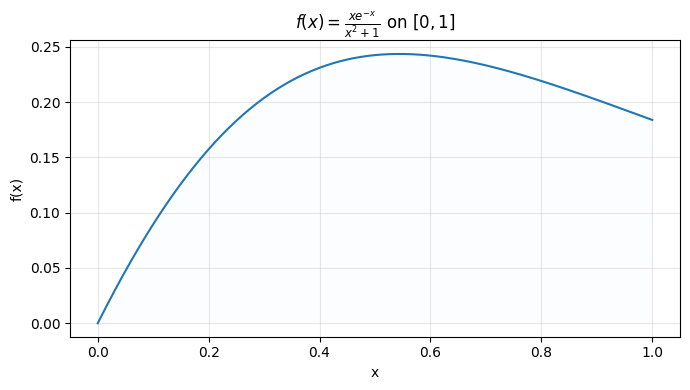

In [19]:
f2 = lambda x: x * np.exp(-x) / (x ** 2 + 1)

xs = np.linspace(0, 1, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs, f2(xs), color="#1f77b4")
ax.fill_between(xs, f2(xs), alpha=0.01)
ax.set_title(r"$f(x) = \frac{xe^{-x}}{x^2+1}$ on $[0,1]$")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
exact2, _ = quad(f2, 0, 1, epsabs=1e-14, epsrel=1e-14)
print(f"reference value (scipy.integrate.quad) = {exact2:.14f}")

ns = [2, 4, 8, 16, 32, 64, 128, 256]
rules = [
    ("Rectangle", composite_rectangle),
    ("Trapezoidal", composite_trapezoidal),
    ("Simpson", composite_simpson),
]

for name, rule in rules:
    print(f"\n{name}:")
    print(f"{'n':>4} {'approx':>16} {'error':>12} {'ratio':>8}")
    prev_err = None
    for n in ns:
        approx = rule(f2, 0, 1, n)
        err = abs(approx - exact2)
        ratio_str = f"{prev_err / err:8.2f}" if prev_err is not None and err > 0 else "       -"
        print(f"{n:>4} {approx:>16.12f} {err:>12.3e} {ratio_str}")
        prev_err = err


reference value (scipy.integrate.quad) = 0.19232940611585

Rectangle:
   n           approx        error    ratio
   2   0.204991594196    1.266e-02        -
   4   0.195431636061    3.102e-03     4.08
   8   0.193101369695    7.720e-04     4.02
  16   0.192522177424    1.928e-04     4.00
  32   0.192377585291    4.818e-05     4.00
  64   0.192341450057    1.204e-05     4.00
 128   0.192332417048    3.011e-06     4.00
 256   0.192330158846    7.527e-07     4.00

Trapezoidal:
   n           approx        error    ratio
   2   0.167291062089    2.504e-02        -
   4   0.186141328142    6.188e-03     4.05
   8   0.190786482102    1.543e-03     4.01
  16   0.191943925899    3.855e-04     4.00
  32   0.192233051661    9.635e-05     4.00
  64   0.192305318476    2.409e-05     4.00
 128   0.192323384267    6.022e-06     4.00
 256   0.192327900657    1.505e-06     4.00

Simpson:
   n           approx        error    ratio
   2   0.192398129354    6.872e-05        -
   4   0.192424750160    9

Both rectangle and trapezoidal rules show ratios converging to $4$, while Simpson's ratios converge to $16$. This matches the theoretical orders $O(h^2)$ and $O(h^4)$ from the lecture, since halving $h$ divides the error by $2^p$ where $p$ is the convergence order.

## Application 3 - tabulating $\operatorname{erf}$ with adaptive trapezoidal

$$\operatorname{erf}(x) = \frac{2}{\sqrt{\pi}}\int_0^x e^{-t^2}\,dt.$$

(The PDF prints $\frac{2}{\pi}$ but the standard error function uses $\frac{2}{\sqrt{\pi}}$; we use the standard definition so we can compare with `scipy.special.erf`.)

In [10]:
integrand = lambda t: np.exp(-t ** 2)
two_over_sqrt_pi = 2.0 / np.sqrt(np.pi)

xs = np.arange(0.1, 1.0 + 1e-12, 0.1)

print(f"{'x':>4} {'adaptive trap':>16} {'scipy quad':>16} {'scipy erf':>16} {'|adq - erf|':>12}")
for x in xs:
    adq = two_over_sqrt_pi * adaptive_trapezoidal(integrand, 0.0, x, eps=1e-10, m=2)
    sci_quad = two_over_sqrt_pi * quad(integrand, 0.0, x, epsabs=1e-14)[0]
    sci_erf = scipy_erf(x)
    print(f"{x:>4.1f} {adq:>16.12f} {sci_quad:>16.12f} {sci_erf:>16.12f} {abs(adq - sci_erf):>12.3e}")


   x    adaptive trap       scipy quad        scipy erf  |adq - erf|
 0.1   0.112462915308   0.112462916018   0.112462916018    7.103e-10
 0.2   0.222702587832   0.222702589210   0.222702589210    1.379e-09
 0.3   0.328626755033   0.328626759459   0.328626759459    4.426e-09
 0.4   0.428392350097   0.428392355047   0.428392355047    4.950e-09
 0.5   0.520499873152   0.520499877813   0.520499877813    4.661e-09
 0.6   0.603856083788   0.603856090848   0.603856090848    7.060e-09
 0.7   0.677801183956   0.677801193837   0.677801193837    9.881e-09
 0.8   0.742100957427   0.742100964708   0.742100964708    7.281e-09
 0.9   0.796908207106   0.796908212423   0.796908212423    5.317e-09
 1.0   0.842700789248   0.842700792950   0.842700792950    3.701e-09


The adaptive trapezoidal results match `scipy.integrate.quad` and `scipy.special.erf` to roughly 10 significant digits, well under the requested tolerance.

## Application 4 - length of the curve $y = \sin(\pi x)$ on $[0,1]$

$$\ell(f) = \int_a^b \sqrt{1 + [f'(x)]^2}\,dx.$$

Here $f'(x) = \pi\cos(\pi x)$, so the integrand is $\sqrt{1 + \pi^2 \cos^2(\pi x)}$. The graph and one half-period are symmetric, and we use adaptive Simpson to approximate the length.

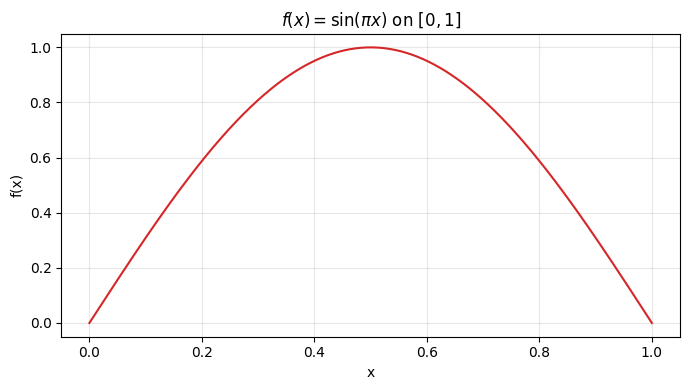

adaptive Simpson length    = 2.304892661489
reference (scipy.quad)     = 2.304892661354
absolute difference        = 1.355e-10


In [11]:
f4 = lambda x: np.sin(np.pi * x)
arc_integrand = lambda x: np.sqrt(1.0 + (np.pi * np.cos(np.pi * x)) ** 2)

xs = np.linspace(0, 1, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs, f4(xs), color="#d62728")
ax.set_title(r"$f(x) = \sin(\pi x)$ on $[0,1]$")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

length_adaptive = adaptive_simpson(arc_integrand, 0.0, 1.0, eps=1e-10, m=2)
length_reference, _ = quad(arc_integrand, 0.0, 1.0, epsabs=1e-14)

print(f"adaptive Simpson length    = {length_adaptive:.12f}")
print(f"reference (scipy.quad)     = {length_reference:.12f}")
print(f"absolute difference        = {abs(length_adaptive - length_reference):.3e}")


## Optional - Application 5

Apply Simpson's rule to $I = \int_0^1 \sin(\sqrt[3]{x})\,dx$ with $n = 2, 4, \ldots, 256$. The integrand is continuous, but its derivatives blow up at $x = 0$ (since $\sqrt[3]{x}$ has a vertical-tangent singularity), so $f \notin C^4[0,1]$ and the $O(h^4)$ Simpson rate does not apply.

### a) Direct application

In [12]:
f5 = lambda x: np.sin(np.cbrt(x))
exact5, _ = quad(f5, 0, 1, epsabs=1e-14, epsrel=1e-14)
print(f"reference value = {exact5:.14f}\n")

ns = [2, 4, 8, 16, 32, 64, 128, 256]
print(f"{'n':>4} {'Simpson':>16} {'error':>12} {'ratio':>8}")
prev_err = None
for n in ns:
    approx = composite_simpson(f5, 0, 1, n)
    err = abs(approx - exact5)
    ratio_str = f"{prev_err / err:8.2f}" if prev_err is not None and err > 0 else "       -"
    print(f"{n:>4} {approx:>16.12f} {err:>12.3e} {ratio_str}")
    prev_err = err


reference value = 0.66973282645180

   n          Simpson        error    ratio
   2   0.615547164540    5.419e-02        -
   4   0.648192138960    2.154e-02     2.52
   8   0.661181361788    8.551e-03     2.52
  16   0.666338923786    3.394e-03     2.52
  32   0.668385931041    1.347e-03     2.52
  64   0.669198307821    5.345e-04     2.52
 128   0.669520702208    2.121e-04     2.52
 256   0.669648644833    8.418e-05     2.52


The error ratios are far below the theoretical $16$ - they hover around $\approx 4$, i.e. the effective rate drops to roughly $O(h^2)$. This is exactly the lecture's warning: when $f \notin C^4[a,b]$, Simpson loses its high-order convergence.

### b) Removing the singularity by change of variables

Let $u = \sqrt[3]{x}$, so $x = u^3$ and $dx = 3u^2\,du$. When $x \in [0,1]$, $u \in [0,1]$:

$$I = \int_0^1 \sin(\sqrt[3]{x})\,dx = \int_0^1 3 u^2 \sin(u)\,du.$$

The new integrand $g(u) = 3u^2 \sin(u)$ is in $C^\infty[0,1]$, so Simpson should recover its $O(h^4)$ rate.

In [13]:
g5 = lambda u: 3.0 * u ** 2 * np.sin(u)

exact5_g, _ = quad(g5, 0, 1, epsabs=1e-14, epsrel=1e-14)
print(f"reference value (transformed) = {exact5_g:.14f}")
print(f"matches original reference?    {np.isclose(exact5, exact5_g, atol=1e-12)}\n")

print(f"{'n':>4} {'Simpson':>16} {'error':>12} {'ratio':>8}")
prev_err = None
for n in ns:
    approx = composite_simpson(g5, 0, 1, n)
    err = abs(approx - exact5_g)
    ratio_str = f"{prev_err / err:8.2f}" if prev_err is not None and err > 0 else "       -"
    print(f"{n:>4} {approx:>16.12f} {err:>12.3e} {ratio_str}")
    prev_err = err


reference value (transformed) = 0.66973282645180
matches original reference?    True

   n          Simpson        error    ratio
   2   0.660448261706    9.285e-03        -
   4   0.669180488494    5.523e-04    16.81
   8   0.669698723382    3.410e-05    16.20
  16   0.669730701472    2.125e-06    16.05
  32   0.669732693741    1.327e-07    16.01
  64   0.669732818159    8.293e-09    16.00
 128   0.669732825934    5.183e-10    16.00
 256   0.669732826419    3.239e-11    16.00


After the change of variables, Simpson's error ratios climb back to $\approx 16$, recovering the theoretical $O(h^4)$ convergence. The transform absorbed the singularity that the original integrand's derivatives had at $x=0$.